In [2]:
import os
import random
import shutil
import yaml
import glob
from IPython.display import Image, display

In [3]:
# Verify NVIDIA GPU Availability
!nvidia-smi

Sat Jun 13 17:26:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Uplode the Candy_data.zip before running next code
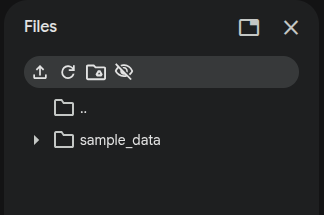

In [5]:
# Unzip images to a custom data folder
!unzip -q /content/candy_data.zip -d /content/custom_data

replace /content/custom_data/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_data/images/008e5689-candy_33.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_data/images/0414530e-candy_58.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_data/images/0425e3c8-candy_59.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


**Ultralytics requires a particular folder structure to store training data for models.**
The root folder is named **“data”**. Inside, there are two main folders:

*   **Train**: These are the actual images used to train the model. In one epoch of training, every image in the train set is passed into the neural network. The training algorithm adjusts the network weights to fit the data in the images.


*   **Validation**: These images are used to check the model's performance at the end of each training epoch.

In each of these folders is a “images” folder and a “labels” folder, which hold the image files and annotation files respectively.

## Split images into train and validation folders

In [6]:
cwd = os.getcwd()
root_dir = os.path.join(cwd,"data")
print("current data dir at : ",root_dir)

# required subfolders
folders = [
    os.path.join(root_dir,"train","images"),
    os.path.join(root_dir,"train","labels"),
    os.path.join(root_dir,"validation","images"),
    os.path.join(root_dir,"validation","labels"),
]

for folder in folders:
  os.makedirs(folder, exist_ok=True)
  print("Created :",folder)

current data dir at :  /content/data
Created : /content/data/train/images
Created : /content/data/train/labels
Created : /content/data/validation/images
Created : /content/data/validation/labels


In [9]:
# Source folders
source_images = os.path.join(cwd, "custom_data", "images")
source_labels = os.path.join(cwd, "custom_data", "labels")

# Destination folders
train_images = os.path.join(root_dir, "train", "images")
train_labels = os.path.join(root_dir, "train", "labels")

val_images = os.path.join(root_dir, "validation", "images")
val_labels = os.path.join(root_dir, "validation", "labels")

# get all image files
image_files = [
    filename for filename in os.listdir(source_images) if filename.lower().endswith((".jpg",".jpeg",".png"))
]

# Shuffle randomly
random.shuffle(image_files)

# Split 90 - 10
split_idx = int(len(image_files)*0.9)

train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

def move_files(files, dest_img, dest_lbl):
  for img_file in files:
    # image path
    src_img = os.path.join(source_images, img_file)
    dst_img = os.path.join(dest_img,img_file)

    # corresponding label path
    base_name = os.path.splitext(img_file)[0]
    label_file = base_name + ".txt"

    src_lbl = os.path.join(source_labels, label_file)
    dst_lbl = os.path.join(dest_lbl, label_file)

    # copying images
    shutil.copy2(src_img, dst_img)

    # move label if it exists
    if os.path.exists(src_lbl):
      shutil.copy2(src_lbl, dst_lbl)
    else:
      print(f"Warning: No label found for {img_file}")
    # Move files
move_files(train_files, train_images, train_labels)
move_files(val_files, val_images, val_labels)

print(f"Training images: {len(train_files)}")
print(f"Validation images: {len(val_files)}")


Training images: 145
Validation images: 17


## Install Requirements (Ultralytics)

Next, we'll install the Ultralytics library in this Google Colab instance. This Python library will be used to train the YOLO model.

In [11]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00


## Configure Training


There's one last step before we can run training: we need to create the Ultralytics training configuration YAML file. This file specifies the location of your train and validation data, and it also defines the model's classes.
Run the code block below to automatically generate a `data.yaml` configuration file. Make sure you have a labelmap file located at `custom_data/classes.txt`. If you used Label Studio or one of my pre-made datasets, it should already be present. If you assembled the dataset another way, you may have to manually create the `classes.txt`.

In [16]:
# define path to classes.txt and run function
path_to_classes_txt = "/content/custom_data/classes.txt"
path_to_data_yaml = "/content/data.yaml"

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):
  # read class.txt to get class name
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt filr not found, Please create it and move to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt,'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0:
        continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # create data dictionary
  data = {
      'path' : '/content/data',
      'train' : 'train/images',
      'val' : 'validation/images',
      'nc' : number_of_classes,
      'name' : classes,
  }

  # write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data,f,sort_keys = False)
  print(f'Created config file at {path_to_data_yaml}')
  return

create_data_yaml(path_to_classes_txt,path_to_data_yaml)
print('\nFile content: \n')
!cat /content/data.yaml


Created config file at /content/data.yaml

File content: 

path: /content/data
train: train/images
val: validation/images
nc: 11
name:
- MMs_peanut
- MMs_regular
- airheads
- gummy_worms
- milky_way
- nerds
- skittles
- snickers
- starbust
- three_musketeers
- twizzlers


## Train Model

## Training Parameters
Now that the data is organized and the config file is created, we're ready to start training! First, there are a few important parameters to decide on.  


**Model architecture & size (`model`):**

There are several YOLO11 models sizes available to train, including `yolo11n.pt`, `yolo11s.pt`, `yolo11m.pt`, `yolo11l.pt`, and `yolo11xl.pt`. Larger models run slower but have higher accuracy, while smaller models run faster but have lower accuracy.If you aren't sure which model size to use, `yolo11s.pt` is a good starting point.

You can also train YOLOv8 or YOLOv5 models by substituting `yolo11` for `yolov8` or `yolov5`.


**Number of epochs (`epochs`)**

In machine learning, one “epoch” is one single pass through the full training dataset. Setting the number of epochs dictates how long the model will train for. The best amount of epochs to use depends on the size of the dataset and the model architecture. If your dataset has less than 200 images, a good starting point is 60 epochs. If your dataset has more than 200 images, a good starting point is 40 epochs.


**Resolution (`imgsz`)**

Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy. YOLO models are typically trained and inferenced at a 640x640 resolution. However, if you want your model to run faster or know you will be working with low-resolution images, try using a lower resolution like 480x480.


In [18]:
!yolo detect train data = /content/data.yaml model = yolo11s.pt epochs = 60 imgsz = 640

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

The training algorithm will parse the images in the training and validation directories and then start training the model. At the end of each training epoch, the program runs the model on the validation dataset and reports the resulting mAP, precision, and recall. As training continues, the mAP should generally increase with each epoch. Training will end once it goes through the number of epochs specified by `epochs`.

> **NOTE:** Make sure to allow training to run to completion, because an optimizer runs at the end of training that strips out unneeded layers from the model.

The best trained model weights will be saved in `content/runs/detect/train/weights/best.pt`. Additional information about training is saved in the `content/runs/detect/train` folder, including a `results.png` file that shows how loss, precision, recall, and mAP progressed over each epoch.

##Test Model

The model has been trained; now it's time to test it! The commands below run the model on the images in the validation folder and then display the results for the first 10 images. This is a good way to confirm your model is working as expected. Click Play on the blocks below to see how your model performs.

In [20]:
!yolo detect predict model = runs/detect/train/weights/best.pt source = data/validation/images save = True

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs

image 1/32 /content/data/validation/images/008e5689-candy_33.jpg: 384x640 1 class_2, 1 class_8, 1 class_9, 1 class_10, 59.8ms
image 2/32 /content/data/validation/images/0414530e-candy_58.jpg: 384x640 1 class_0, 1 class_8, 1 class_9, 2 class_10s, 10.6ms
image 3/32 /content/data/validation/images/0873acf3-candy_40.jpg: 384x640 1 class_0, 1 class_2, 1 class_6, 1 class_10, 12.2ms
image 4/32 /content/data/validation/images/09f85b64-candy_19.jpg: 384x640 1 class_1, 1 class_2, 1 class_9, 1 class_10, 10.8ms
image 5/32 /content/data/validation/images/0b01ef90-candy_26.jpg: 384x640 1 class_0, 1 class_1, 2 class_2s, 1 class_8, 10.8ms
image 6/32 /content/data/validation/images/0f6faea3-candy_83.jpg: 480x640 2 class_0s, 2 class_1s, 2 class_2s, 1 class_9, 63.4ms
image 7/32 /content/data/validation/images/1a146567-candy_107.jpg: 480x64

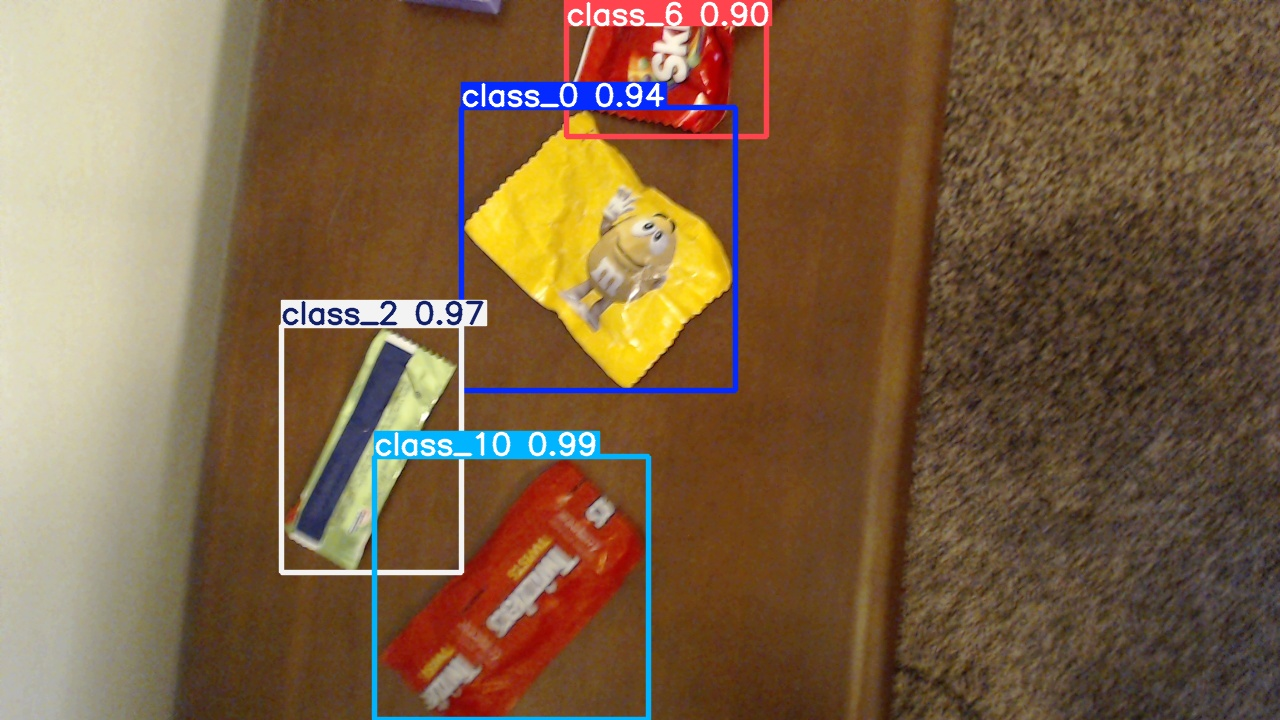

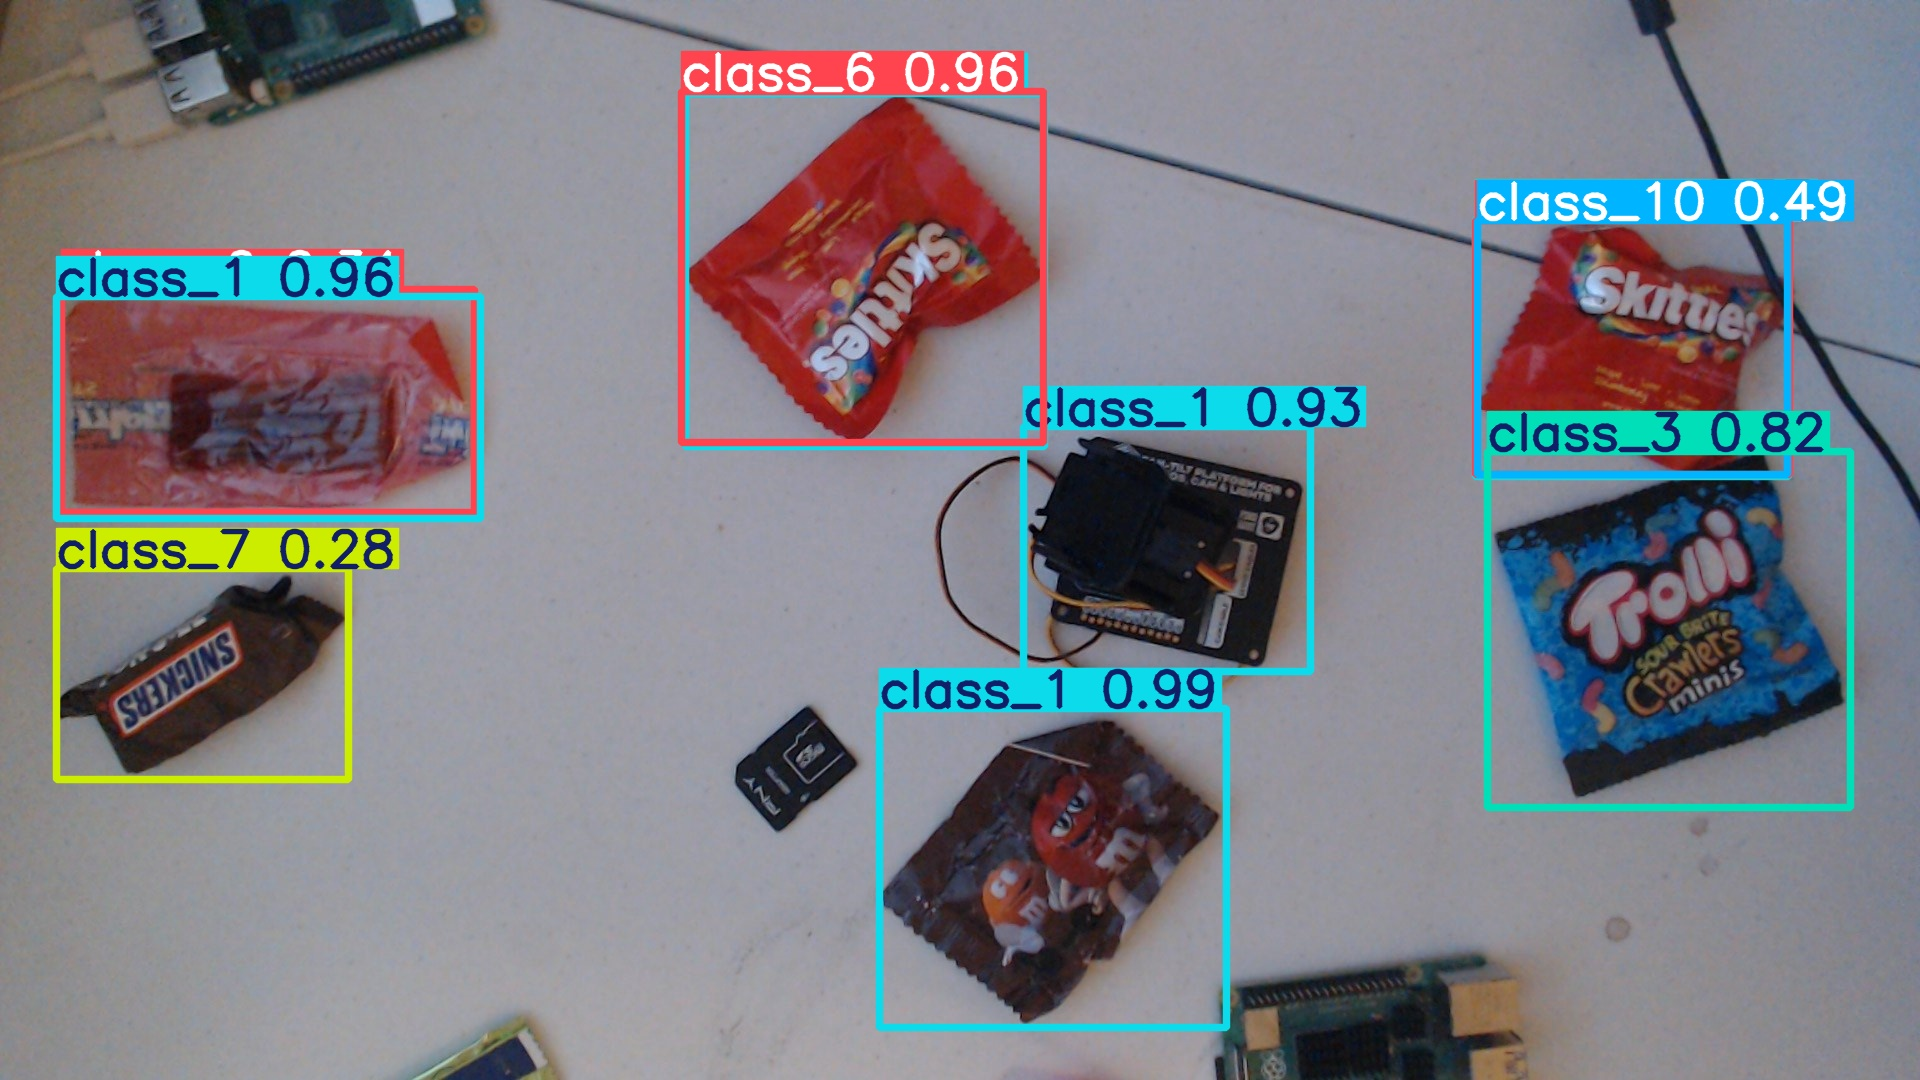

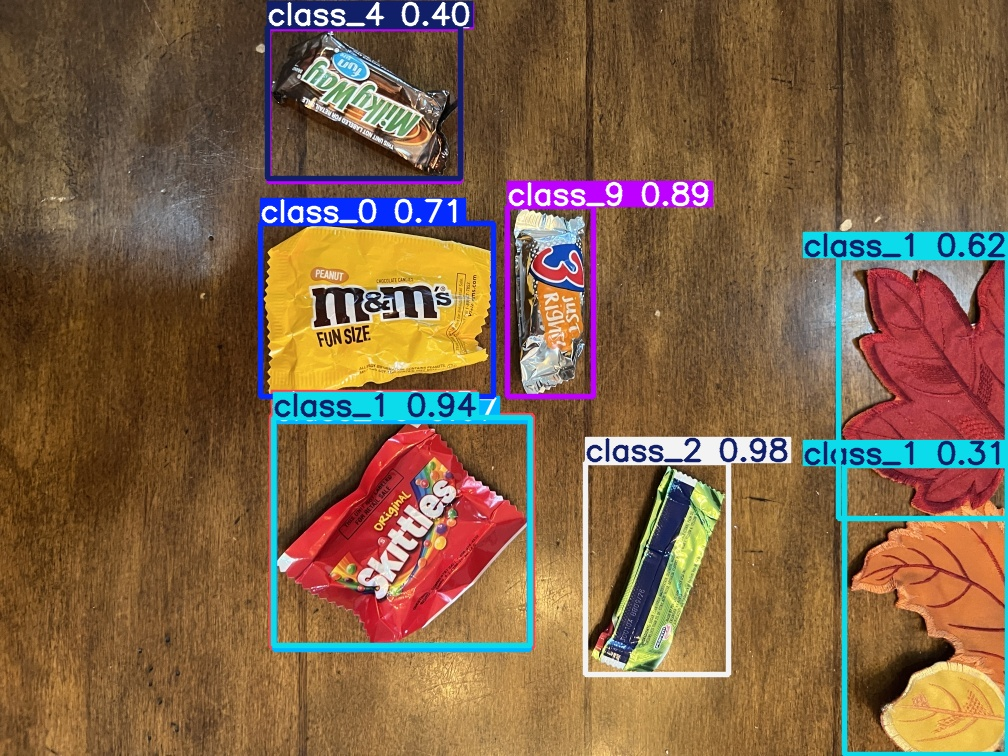

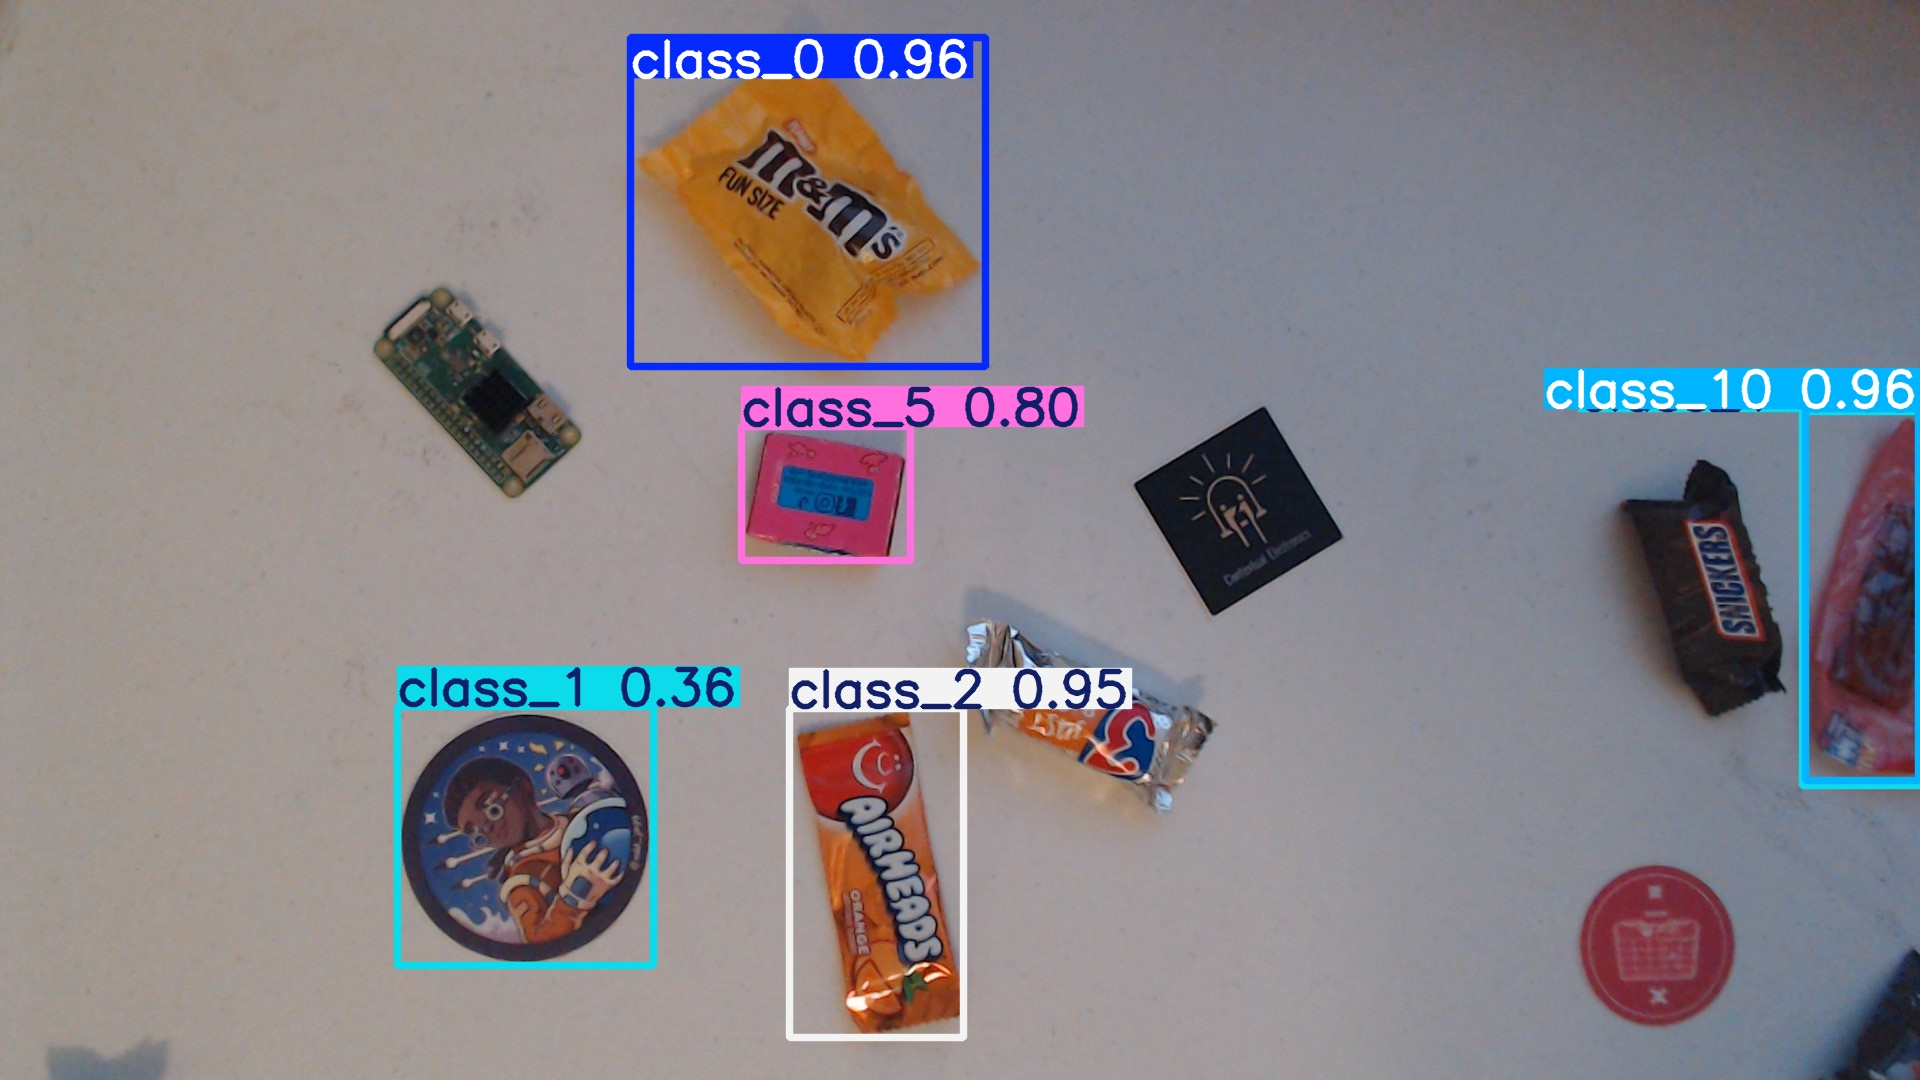

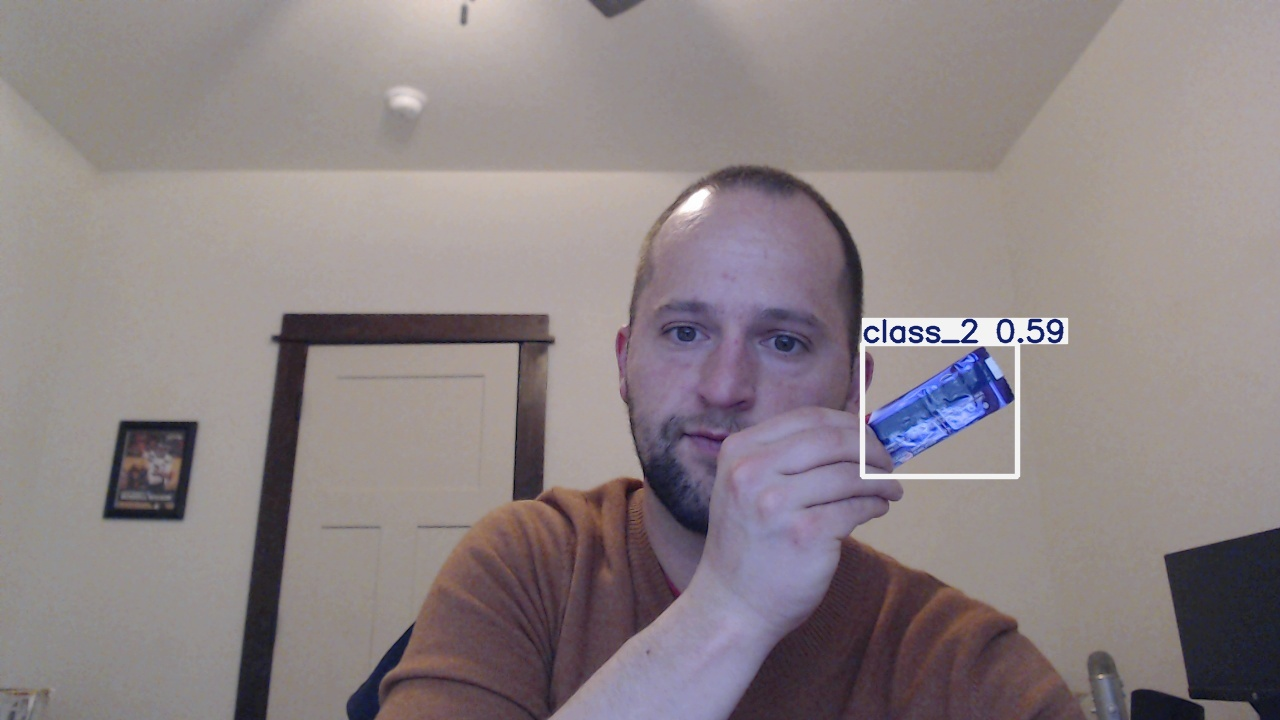

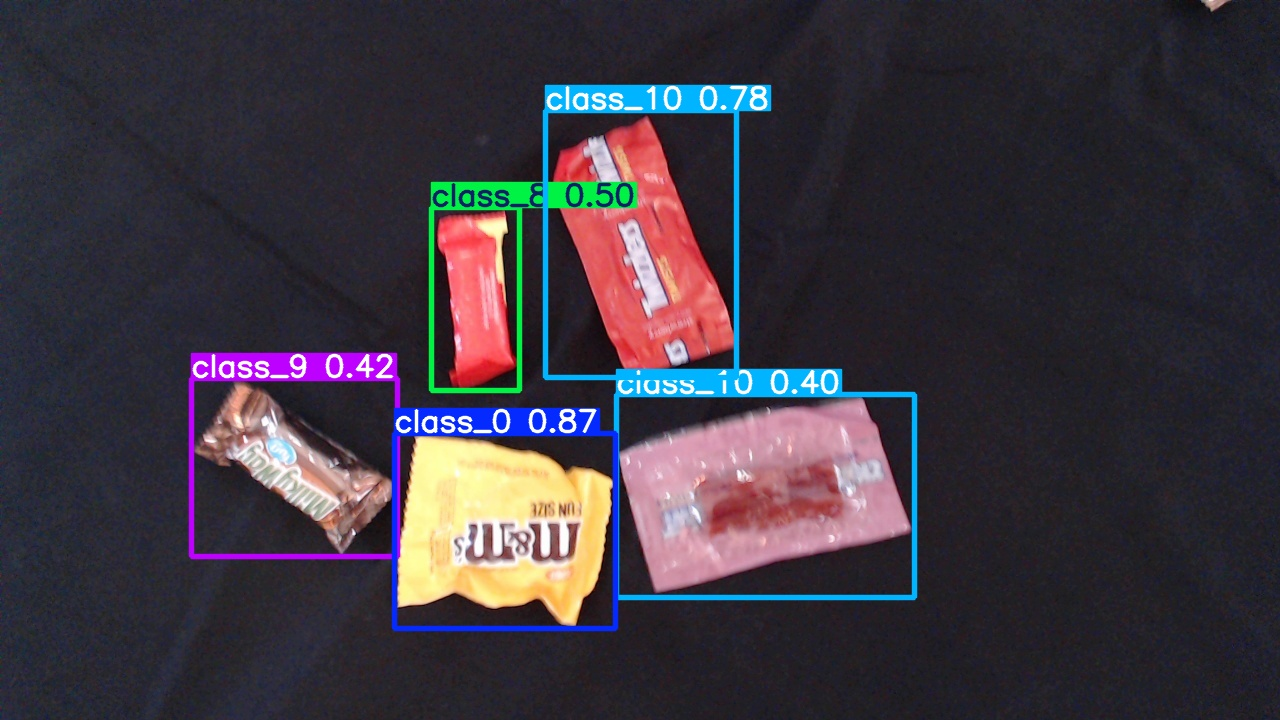

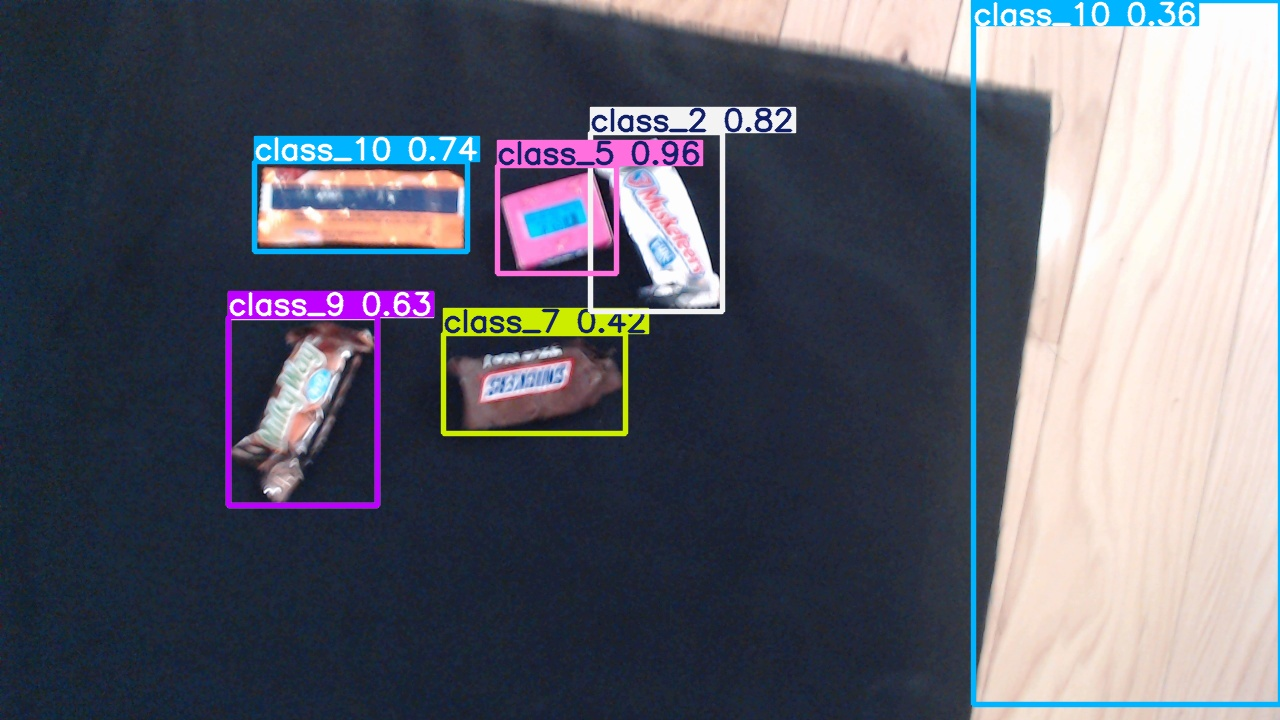

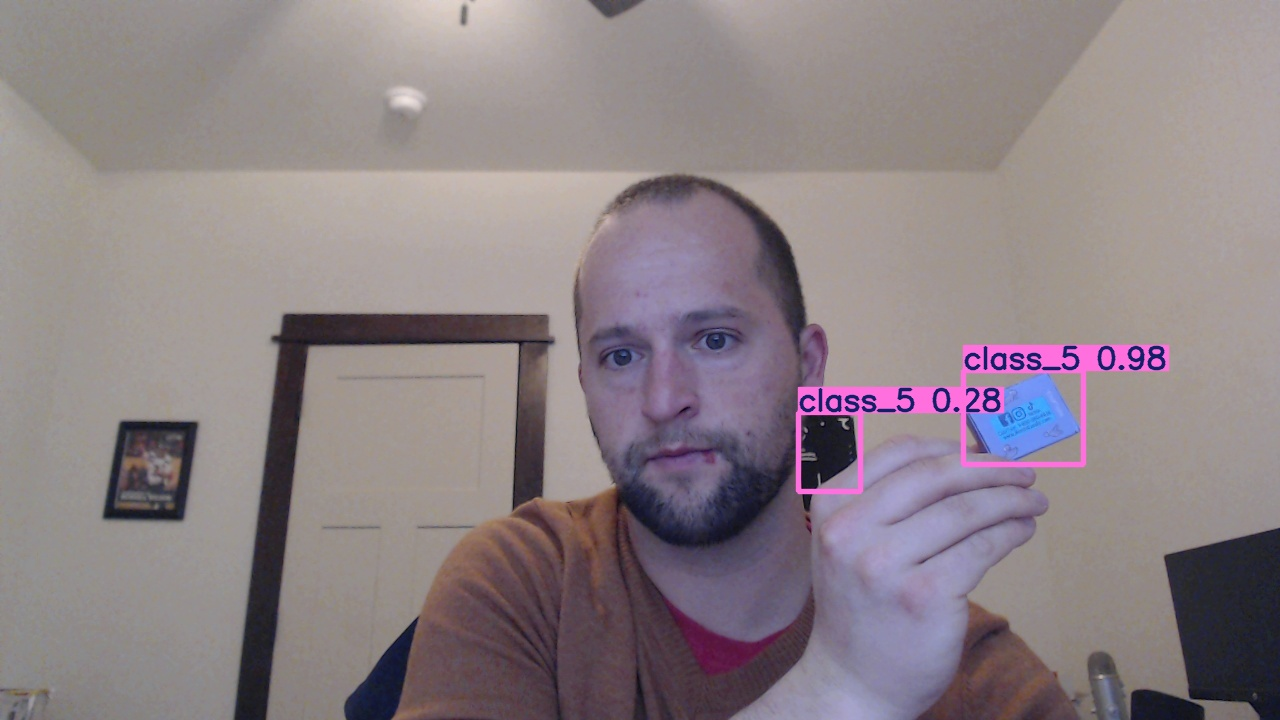

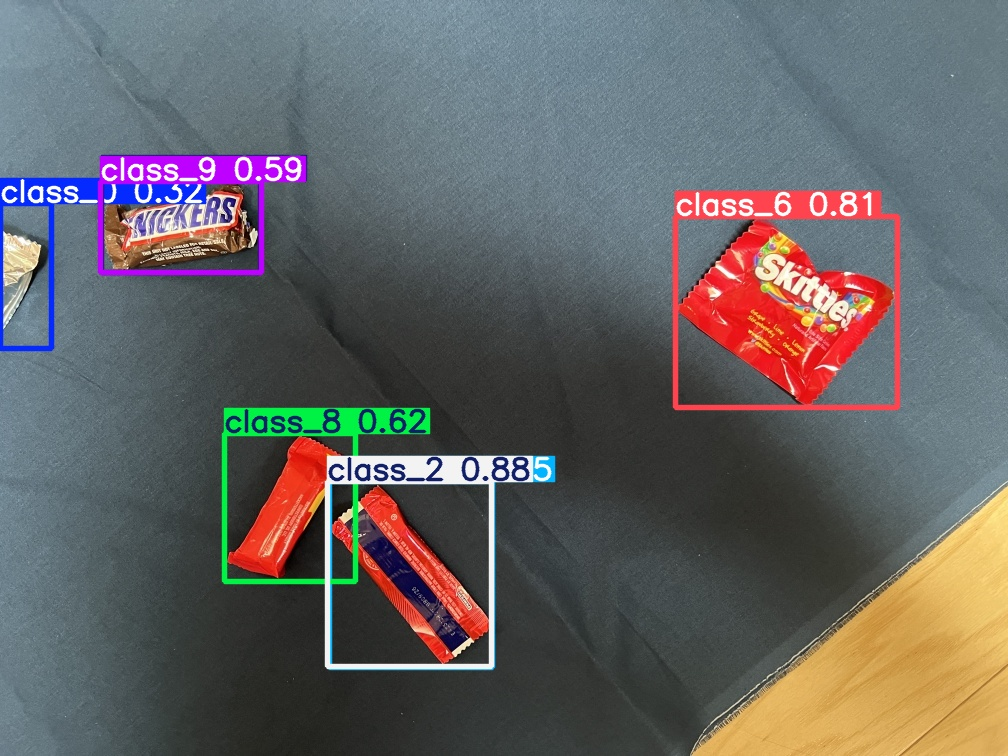

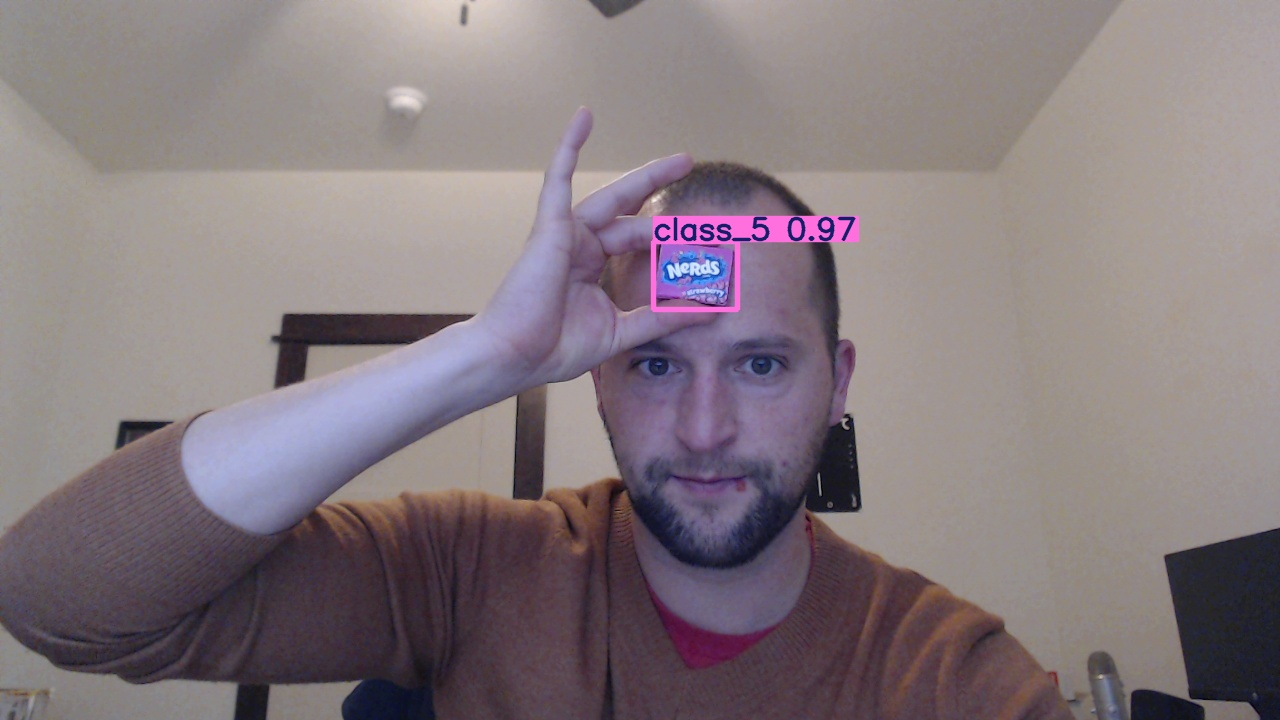

In [21]:
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height = 400))
  print('\n')

The model should draw a box around each object of interest in each image. If it isn't doing a good job of detecting objects, here are a few tips:  

1. Double-check your dataset to make sure there are no labeling errors or conflicting examples.
2. Increase the number of epochs used for training.
3. Use a larger model size (e.g. `yolo11l.pt`).
4. Add more images to the training dataset.